# 05 - Duplicate and Contradiction Detection

## 1. Imports and setup

In [1]:
import re
import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "promise_final.csv"
FIGURES_DIR = PROJECT_ROOT / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
SBERT_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

if torch.backends.mps.is_available():
    DEVICE = "mps"
elif torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"
print(f"Device: {DEVICE}")

df = pd.read_csv(DATA_PATH)
print(f"Data: {len(df)} requirements across {df['project_id'].nunique()} projects")

def save_fig(name):
    for ext in ["pdf", "png"]:
        plt.savefig(FIGURES_DIR / f"{name}.{ext}", dpi=300, bbox_inches='tight')

Device: mps
Data: 3677 requirements across 88 projects


## 2. Project distribution

In [2]:
project_sizes = df.groupby("project_id").size().sort_values(ascending=False)
print(f"Projects: {len(project_sizes)}")
print(f"Mean reqs/project: {project_sizes.mean():.1f}")
print(f"Median reqs/project: {project_sizes.median():.1f}")
print(f"Largest project: {project_sizes.iloc[0]} reqs")
print(f"Smallest project: {project_sizes.iloc[-1]} reqs")

project_pairs = (project_sizes * (project_sizes - 1)) // 2
print(f"\nTotal intra-project pairs across all projects: {int(project_pairs.sum())}")

Projects: 88
Mean reqs/project: 41.8
Median reqs/project: 25.0
Largest project: 243 reqs
Smallest project: 1 reqs

Total intra-project pairs across all projects: 171879


## 3. Encode all requirements with SBERT

In [3]:
sbert = SentenceTransformer(SBERT_MODEL, device=DEVICE)
print(f"SBERT loaded. Embedding dim: {sbert.get_embedding_dimension()}")

texts = df["text"].tolist()
embeddings = sbert.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
print(f"Embeddings shape: {embeddings.shape}")

df = df.reset_index(drop=True)
embeddings_by_project = {
    pid: embeddings[df.index[df["project_id"] == pid].tolist()]
    for pid in df["project_id"].unique()
}
texts_by_project = {
    pid: df.loc[df["project_id"] == pid, "text"].tolist()
    for pid in df["project_id"].unique()
}
indices_by_project = {
    pid: df.index[df["project_id"] == pid].tolist()
    for pid in df["project_id"].unique()
}
print(f"Indexed embeddings for {len(embeddings_by_project)} projects.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

SBERT loaded. Embedding dim: 384


Batches:   0%|          | 0/58 [00:00<?, ?it/s]

Embeddings shape: (3677, 384)
Indexed embeddings for 88 projects.


## 4. Duplicate detection (intra-project, cosine ≥ DUP_THRESHOLD)

In [4]:
DUP_THRESHOLD = 0.85

def find_duplicates_in_project(emb_proj, texts_proj, indices_proj, threshold):
    """Return list of (i_global, j_global, sim, text_i, text_j) for pairs above threshold."""
    n = len(texts_proj)
    if n < 2:
        return []
    sim_matrix = cosine_similarity(emb_proj)
    pairs = []
    for i in range(n):
        for j in range(i + 1, n):
            if sim_matrix[i, j] >= threshold:
                pairs.append((
                    indices_proj[i], indices_proj[j],
                    float(sim_matrix[i, j]),
                    texts_proj[i], texts_proj[j],
                ))
    return pairs

duplicate_pairs = []
for pid in df["project_id"].unique():
    duplicate_pairs.extend(find_duplicates_in_project(
        embeddings_by_project[pid],
        texts_by_project[pid],
        indices_by_project[pid],
        DUP_THRESHOLD,
    ))

print(f"Duplicate pairs detected at threshold {DUP_THRESHOLD}: {len(duplicate_pairs)}")
print(f"Across {df['project_id'].nunique()} projects, average {len(duplicate_pairs)/df['project_id'].nunique():.2f} dupes per project.")

Duplicate pairs detected at threshold 0.85: 383
Across 88 projects, average 4.35 dupes per project.


## 5. Threshold sensitivity

  Threshold 0.7: 3093 duplicate pairs
  Threshold 0.75: 1590 duplicate pairs
  Threshold 0.8: 819 duplicate pairs
  Threshold 0.85: 383 duplicate pairs
  Threshold 0.9: 153 duplicate pairs
  Threshold 0.95: 59 duplicate pairs


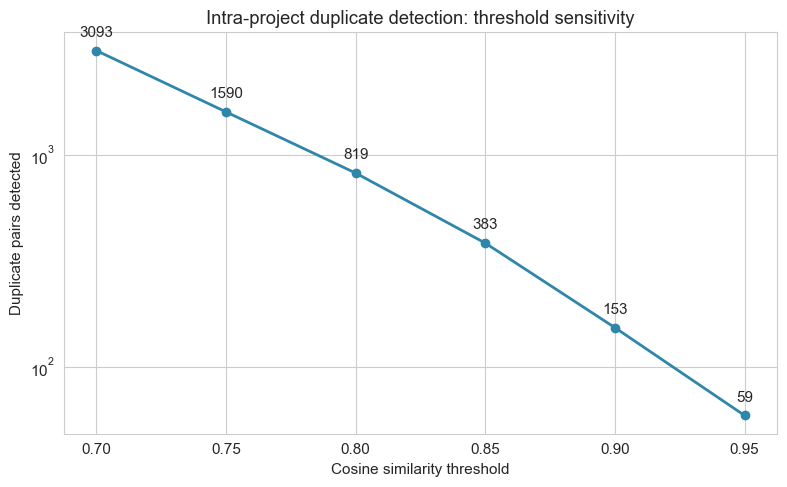

In [5]:
thresholds = [0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
counts = []
for t in thresholds:
    n = 0
    for pid in df["project_id"].unique():
        n += len(find_duplicates_in_project(
            embeddings_by_project[pid],
            texts_by_project[pid],
            indices_by_project[pid],
            t,
        ))
    counts.append(n)
    print(f"  Threshold {t}: {n} duplicate pairs")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, counts, marker="o", color="#2E86AB", linewidth=2)
for t, c in zip(thresholds, counts):
    ax.annotate(f"{c}", (t, c), textcoords="offset points", xytext=(0, 10), ha="center")
ax.set_xlabel("Cosine similarity threshold")
ax.set_ylabel("Duplicate pairs detected")
ax.set_title("Intra-project duplicate detection: threshold sensitivity")
ax.set_yscale("log")
plt.tight_layout()
save_fig("fig_dupcon_01_threshold_sensitivity")
plt.show()

## 6. Contradiction detection (SBERT retrieval + rule-based conflict check)

In [6]:
CONTRADICTION_SIM_MIN = 0.65
CONTRADICTION_SIM_MAX = 0.98

NEGATION_PATTERNS = [
    r"\bnot\b", r"\bnever\b", r"\bcannot\b", r"\bcan't\b",
    r"\bwon't\b", r"\bwouldn't\b", r"\bdo not\b", r"\bdoes not\b",
    r"\bshall not\b", r"\bmust not\b", r"\bno longer\b",
]
NEGATION_RE = re.compile("|".join(NEGATION_PATTERNS), re.IGNORECASE)

QTY_RE = re.compile(
    r"(\d+(?:\.\d+)?)\s*"
    r"(seconds?|secs?|ms|milliseconds?|minutes?|mins?|hours?|hrs?|days?|weeks?|months?|years?|"
    r"%|percent|tb|gb|mb|kb|terabytes?|gigabytes?|megabytes?|kilobytes?|\$|dollars?|usd)",
    re.IGNORECASE,
)

def has_negation(text):
    return bool(NEGATION_RE.search(text))

def extract_quantities(text):
    q = {}
    for val, unit in QTY_RE.findall(text):
        q.setdefault(unit.lower().rstrip("s"), set()).add(float(val))
    return q

def detect_conflicts(t1, t2):
    """Return conflict types between two texts (negation flip / numerical mismatch)."""
    conflicts = []
    if has_negation(t1) != has_negation(t2):
        conflicts.append("negation")
    q1, q2 = extract_quantities(t1), extract_quantities(t2)
    if any(q1[u] != q2[u] for u in set(q1) & set(q2)):
        conflicts.append("numerical")
    return conflicts

contradiction_pairs = []
for pid in df["project_id"].unique():
    emb = embeddings_by_project[pid]
    texts_proj = texts_by_project[pid]
    indices = indices_by_project[pid]
    n = len(texts_proj)
    if n < 2:
        continue
    sim_matrix = cosine_similarity(emb)
    for i in range(n):
        for j in range(i + 1, n):
            s = sim_matrix[i, j]
            if not (CONTRADICTION_SIM_MIN <= s <= CONTRADICTION_SIM_MAX):
                continue
            conflicts = detect_conflicts(texts_proj[i], texts_proj[j])
            if conflicts:
                contradiction_pairs.append((
                    indices[i], indices[j], float(s), conflicts,
                    texts_proj[i], texts_proj[j],
                ))

print(f"Contradiction pairs (similar + rule-flagged): {len(contradiction_pairs)}")
n_neg = sum(1 for p in contradiction_pairs if "negation" in p[3])
n_num = sum(1 for p in contradiction_pairs if "numerical" in p[3])
n_both = sum(1 for p in contradiction_pairs if "negation" in p[3] and "numerical" in p[3])
print(f"  ...with negation flip: {n_neg}")
print(f"  ...with numerical mismatch: {n_num}")
print(f"  ...with both: {n_both}")

Contradiction pairs (similar + rule-flagged): 413
  ...with negation flip: 392
  ...with numerical mismatch: 28
  ...with both: 7


## 7. Save embeddings and detection metrics

In [7]:
embeddings_path = MODELS_DIR / "sbert_embeddings.npz"
np.savez_compressed(
    embeddings_path,
    embeddings=embeddings.astype(np.float32),
    project_id=df["project_id"].values,
    index=df.index.values,
)
print(f"Embeddings saved: {embeddings_path} ({embeddings_path.stat().st_size / 1024:.1f} KB)")

detection_results = {
    "sbert_model": SBERT_MODEL,
    "n_requirements": int(len(df)),
    "n_projects": int(df["project_id"].nunique()),
    "duplicate_threshold": DUP_THRESHOLD,
    "n_duplicate_pairs": len(duplicate_pairs),
    "duplicate_threshold_sensitivity": {str(t): c for t, c in zip(thresholds, counts)},
    "contradiction_method": "SBERT retrieval + rule-based check",
    "contradiction_sim_min": CONTRADICTION_SIM_MIN,
    "contradiction_sim_max": CONTRADICTION_SIM_MAX,
    "n_contradiction_pairs": len(contradiction_pairs),
    "contradiction_breakdown": {
        "negation_flip": int(sum(1 for p in contradiction_pairs if "negation" in p[3])),
        "numerical_mismatch": int(sum(1 for p in contradiction_pairs if "numerical" in p[3])),
        "both": int(sum(1 for p in contradiction_pairs if "negation" in p[3] and "numerical" in p[3])),
    },
}

with open(MODELS_DIR / "dupcon_metrics.json", "w") as f:
    json.dump(detection_results, f, indent=2)
print(f"Metrics saved: {MODELS_DIR / 'dupcon_metrics.json'}")
print(f"\nFinal counts:")
print(f"  Duplicates (sim >= {DUP_THRESHOLD}): {len(duplicate_pairs)}")
print(f"  Contradictions (SBERT retrieval + rule): {len(contradiction_pairs)}")

Embeddings saved: /Users/luciano/Developer/requirements-analyzer/models/sbert_embeddings.npz (5092.2 KB)
Metrics saved: /Users/luciano/Developer/requirements-analyzer/models/dupcon_metrics.json

Final counts:
  Duplicates (sim >= 0.85): 383
  Contradictions (SBERT retrieval + rule): 413
